In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd

# Load the files from the D604 folder in Downloads
images = np.load(r"C:\Users\warre\Downloads\D604\images.npy")
labels = pd.read_csv(r"C:\Users\warre\Downloads\D604\labels.csv")

# Print the shapes of the data
print(images.shape)  # Expected output: (4750, 128, 128, 3)
print(labels.shape)  # Expected output: (4750, 1)


(4750, 128, 128, 3)
(4750, 1)


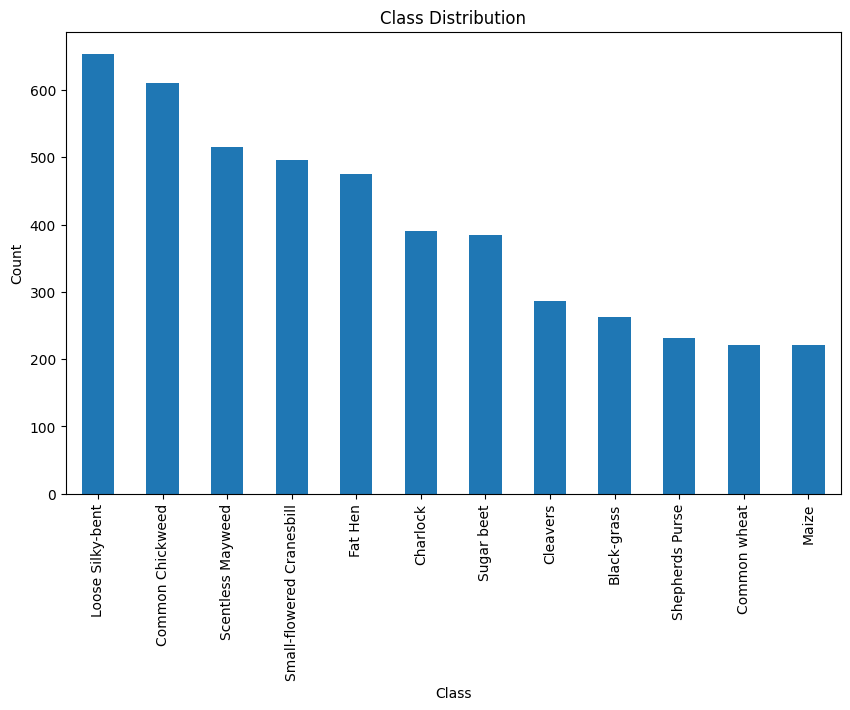

In [2]:
import matplotlib.pyplot as plt

# Use the correct column name 'Label'
class_distribution = labels['Label'].value_counts()
class_distribution.plot(kind='bar', figsize=(10, 6))
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

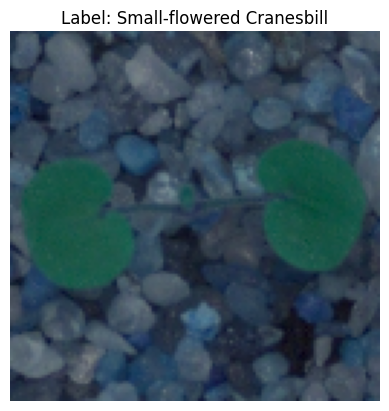

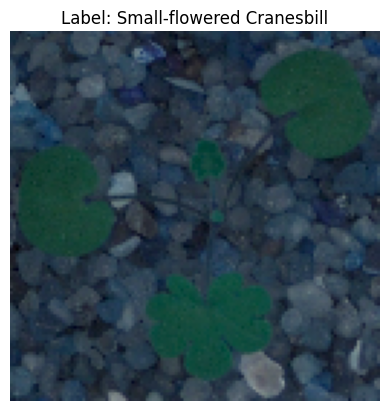

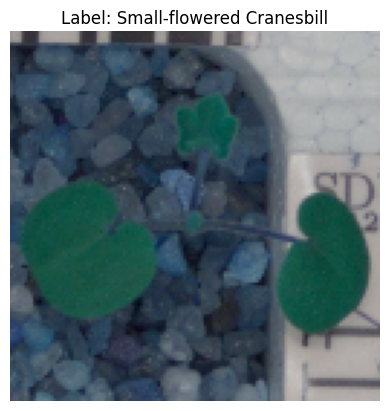

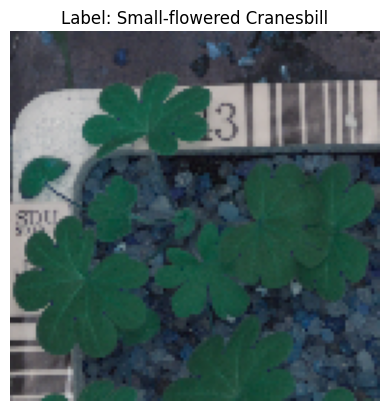

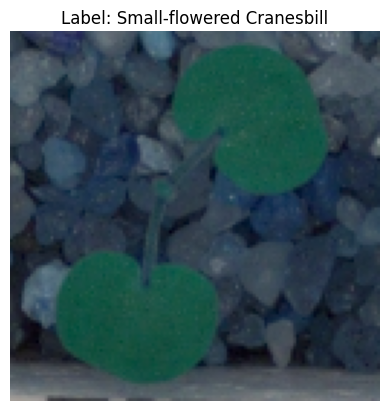

In [3]:
for i in range(5):
    plt.imshow(images[i])
    plt.title(f"Label: {labels.iloc[i, 0]}")
    plt.axis('off')
    plt.show()

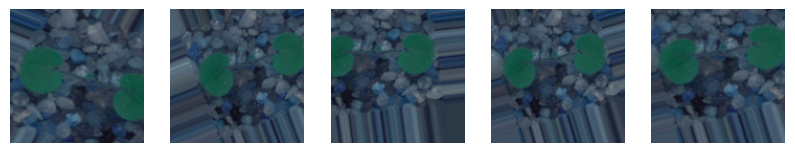

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Select a single image to test augmentation
sample_image = images[0]  # Pick the first image
sample_image = sample_image.reshape((1,) + sample_image.shape)  # Reshape to (1, 128, 128, 3)

# Generate augmented images
augmented_images = datagen.flow(sample_image, batch_size=1)

# Display 5 augmented images
plt.figure(figsize=(10, 10))
for i in range(5):
    augmented_image = next(augmented_images)[0].astype('uint8')  # Get the next augmented image
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_image)
    plt.axis('off')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

# Split the data
d604task1_X_train, d604task1_X_temp, d604task1_y_train, d604task1_y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42
)
d604task1_X_val, d604task1_X_test, d604task1_y_val, d604task1_y_test = train_test_split(
    d604task1_X_temp, d604task1_y_temp, test_size=0.5, random_state=42
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5)

In [14]:
# Normalize the images
sample_images = images / 255.0

In [15]:
!pip install tensorflow

from sklearn.preprocessing import LabelEncoder

# Fit on all labels *before* splitting
label_encoder = LabelEncoder()
label_encoder.fit(labels)

# Now split the data
from sklearn.model_selection import train_test_split
d604task1_X_train, d604task1_X_temp, d604task1_y_train, d604task1_y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42
)
d604task1_X_val, d604task1_X_test, d604task1_y_val, d604task1_y_test = train_test_split(
    d604task1_X_temp, d604task1_y_temp, test_size=0.5, random_state=42
)

# Fit the label encoder
label_encoder.fit(labels.values.ravel())

# Encode the splits
y_train = label_encoder.transform(d604task1_y_train.values.ravel())
y_val = label_encoder.transform(d604task1_y_val.values.ravel())
y_test = label_encoder.transform(d604task1_y_test.values.ravel())


label_encoder.fit(d604task1_y_train.values.ravel())
y_train = label_encoder.transform(d604task1_y_train.values.ravel())
y_val = label_encoder.transform(d604task1_y_val.values.ravel())
y_test = label_encoder.transform(d604task1_y_test.values.ravel())

from tensorflow.keras.utils import to_categorical

y_train_encoded = to_categorical(y_train, num_classes=12)
y_val_encoded = to_categorical(y_val, num_classes=12)
y_test_encoded = to_categorical(y_test, num_classes=12)



C:\Users\warre\OneDrive\tf310_env\lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Define the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(12, activation='softmax')
])

# Display the model summary
model.summary()



C:\Users\warre\OneDrive\tf310_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │           1,548 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,393,868 (28.21 MB)

 Trainable params: 7,393,868 (28.21 MB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


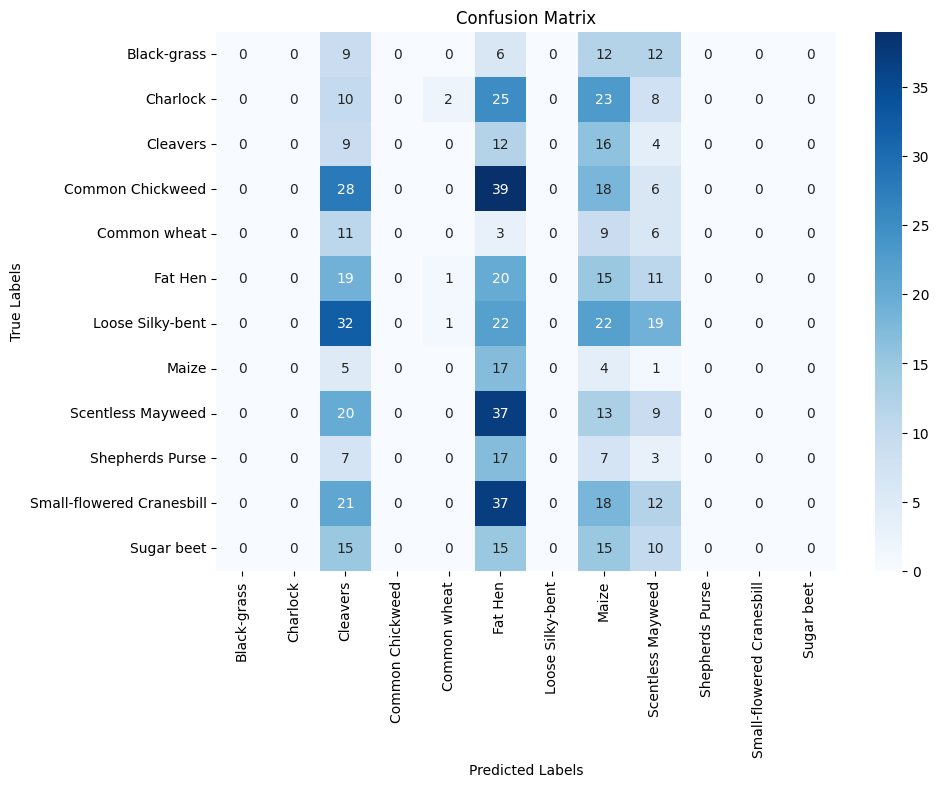

In [18]:
import numpy as np

# Get true class indices for the test set
y_true = np.argmax(y_test_encoded, axis=1)

# Get predicted class indices for the test set
y_pred_probs = model.predict(d604task1_X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Get class names from your label encoder
class_names = label_encoder.classes_

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [20]:
# Compile the model before training
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    d604task1_X_train, y_train_encoded,
    epochs=50,
    batch_size=32,
    validation_data=(d604task1_X_val, y_val_encoded),
    callbacks=[early_stopping]
)

train_loss, train_acc = model.evaluate(d604task1_X_train, y_train_encoded, verbose=0)
val_loss, val_acc = model.evaluate(d604task1_X_val, y_val_encoded, verbose=0)
print(f"Training Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")
print(f"Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.1022 - loss: 77.4372 - val_accuracy: 0.1419 - val_loss: 2.4562
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 144ms/step - accuracy: 0.1490 - loss: 2.4291 - val_accuracy: 0.1419 - val_loss: 2.4724
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.1478 - loss: 2.4219 - val_accuracy: 0.1376 - val_loss: 2.4484
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.1842 - loss: 2.3333 - val_accuracy: 0.1376 - val_loss: 2.4247
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.2101 - loss: 2.2744 - val_accuracy: 0.1390 - val_loss: 2.4784
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.2555 - loss: 2.1753 - val_accuracy: 0.1489 - val_loss: 2.6239
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.3140 - loss: 2.0280 - val_accuracy: 0.1433 - val_loss: 2.7768
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.3320 - loss: 

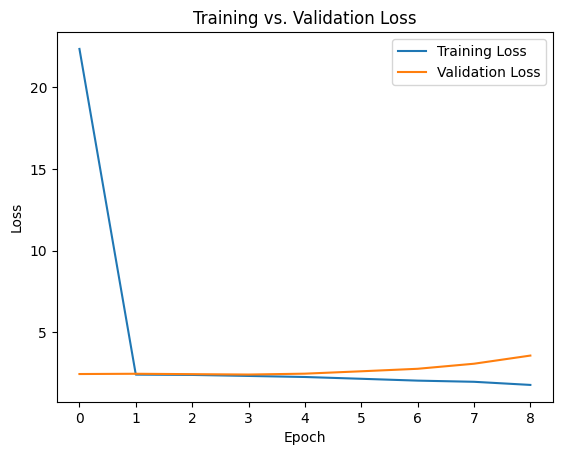

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()
plt.show()

In [22]:
import os

notebook_path = "D604 Task 1 Neural Networks.ipynb"
output_pdf = "D604 Task 1 Neural Networks.pdf"

# Convert notebook to PDF using nbconvert
os.system(f'jupyter nbconvert --to pdf "{notebook_path}" --output "{output_pdf}"')
print(f"Notebook exported as {output_pdf}")

Notebook exported as D604 Task 1 Neural Networks.pdf
